In [1]:
from xgw.gromov_wasserstein_m_dist import gw_m_convex, classical_gw

# open and convert to grayscale
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt



In [2]:
fname = 'hand.png'
img = Image.open(fname).convert('L')
img_array = np.array(img)
img_array.shape

(228, 455)

(-0.5, 204.5, 187.5, -0.5)

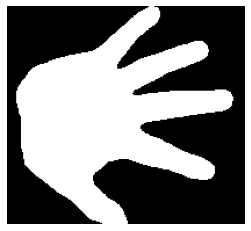

In [94]:
crop = img_array[20:-20, 250:]
# binarize
crop = (crop > 128).astype(float)
plt.imshow(crop, cmap='gray')
plt.axis('off')

(32, 35)


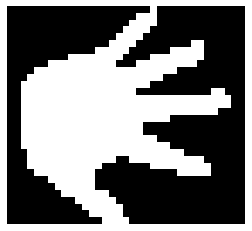

In [95]:
# downsample image
ds_factor = 6
crop = crop[::ds_factor, ::ds_factor]
plt.imshow(crop, cmap='gray')
plt.axis('off')
print(crop.shape)


<Axes: ylabel='Frequency'>

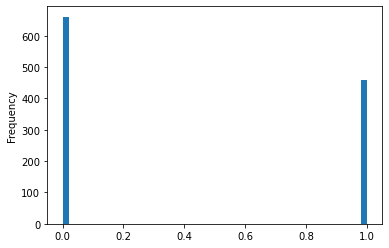

In [96]:
import pandas as pd
pd.Series(crop.flatten()).sort_values().plot.hist(bins=50)

In [97]:
i_mesh, j_mesh = np.meshgrid(np.arange(crop.shape[1], dtype=float), np.arange(crop.shape[0], dtype=float), indexing='ij')
points = np.vstack([i_mesh.flatten(), j_mesh.flatten()]).T
points /= np.max(np.linalg.norm(points, axis=1, keepdims=True))

# i_mesh, j_mesh = np.meshgrid(np.arange(crop.shape[1], dtype=float), np.arange(crop.shape[0], dtype=float), indexing='ij')
# i_mesh *= -1
# points_flipped = np.vstack([i_mesh.flatten(), j_mesh.flatten()]).T
# points_flipped /= np.max(np.linalg.norm(points_flipped, axis=1, keepdims=True))

mu = crop.flatten() / crop.sum()

mu_flipped = crop[::-1].flatten() / crop.sum()

In [98]:
# plt.imshow(np.arange(100).reshape(10,10))
# plt.colorbar()

In [99]:
T, plan, c, _, _ = gw_m_convex(mu, points, mu_flipped, points, {}, cost='CGW', gap_tol=1e-15, iter_max=100, FW_iter=10, p_plus_implementation='cdd') 

2026-03-11 22:25:55.583 - e_base (1120, 1120, 4), pi (1120, 1120)
2026-03-11 22:25:55.657 - e_base (1120, 1120, 4), pi (1120, 1120)
2026-03-11 22:25:55.710 - e_base (1120, 1120, 4), pi (1120, 1120)
2026-03-11 22:25:55.760 - e_base (1120, 1120, 4), pi (1120, 1120)
2026-03-11 22:25:55.814 - e_base (1120, 1120, 4), pi (1120, 1120)
2026-03-11 22:25:55.826 - Adding new half-planes and vertices to the bounding boxes
2026-03-11 22:25:55.826 - Computing vertices from half-planes: A shape (5, 4), b shape (5,)
2026-03-11 22:25:55.829 - Feasibility check result: True
2026-03-11 22:25:55.832 - Linprog result:        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
       success: True
        status: 0
           fun: 0.0
             x: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
           nit: 0
         lower:  residual: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
                marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
         upper:  residual: [  

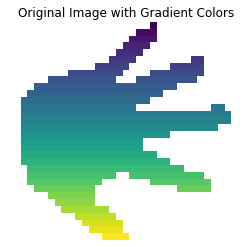

In [100]:
# vertical gradient
binary = crop.astype(bool)
H, W = binary.shape
grad = np.linspace(0, 1, H)[:, None]
grad = np.repeat(grad, W, axis=1)

# convert gradient to colors
cmap = plt.cm.viridis
colors = cmap(grad)[..., :3]

# apply mask
colored = np.ones((H, W, 3))  # white background
colored[binary] = colors[binary]

plt.imshow(colored)
plt.axis("off")
plt.title('Original Image with Gradient Colors')
plt.show()

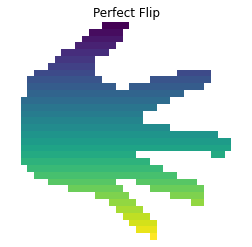

In [101]:
# vertical gradient
binary = crop[::-1].astype(bool)
H, W = binary.shape
grad = np.linspace(0, 1, H)[:, None]
grad = np.repeat(grad, W, axis=1)

# convert gradient to colors
cmap = plt.cm.viridis
colors = cmap(grad)[..., :3]

# apply mask
colored = np.ones((H, W, 3))  # white background
colored[binary] = colors[binary]

plt.imshow(colored)
plt.title('Perfect Flip')
plt.axis("off")
plt.show()

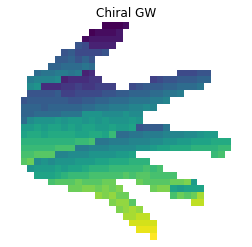

In [109]:
# perm = plan.argmax(axis=1)
# # vertical gradient
# binary = crop.astype(bool)
# H, W = binary.shape
# grad = np.linspace(0, 1, H)[:, None]
# grad = np.repeat(grad, W, axis=1)

# # convert gradient to colors
# cmap = plt.cm.viridis
# colors = cmap(grad)[..., :3]

# # apply mask
# colored = np.ones((H, W, 3))  # white background
# transported_colors = colors.reshape(-1,3)[perm].reshape(colored.shape)
# colored[binary] = transported_colors[binary]

# plt.imshow(colored[::-1])
# plt.title('Chiral GW')
# plt.axis("off")
# plt.show()

perm = plan.argmax(axis=0)
# vertical gradient
binary = crop[::-1].astype(bool)
H, W = binary.shape
grad = np.linspace(0, 1, H)[:, None]
grad = np.repeat(grad, W, axis=1)

# convert gradient to colors
cmap = plt.cm.viridis
colors = cmap(grad)[..., :3][::-1]

# apply mask
colored = np.ones((H, W, 3))  # white background
transported_colors = colors.reshape(-1,3)[perm].reshape(colored.shape)
colored[binary] = transported_colors[binary]

plt.imshow(colored)
plt.axis("off")
plt.title('Chiral GW')
plt.show()

In [103]:
# np.array([[0,0,1],[1,0,0],[0,1,0]]).argmax(axis=0)

In [106]:
_, plan_gw, _, _, _ = classical_gw(mu, points, mu_flipped, points, {},  cost_tol=1e-18, iter_max=200, FW_iter=100, p_plus_implementation='cdd') 

2026-03-11 22:34:57.091 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.177 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.238 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.298 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.366 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.433 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.498 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.571 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.658 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.725 - e_base (1120, 1120, 5), pi (1120, 1120)
2026-03-11 22:34:57.738 - Adding new half-planes and vertices to the bounding boxes
2026-03-11 22:34:57.739 - Computing vertices from half-planes: A shape (10, 5), b shape (10,)
2026-03-11 22:34:57.743 - Feasibility check result: False
2026-03-11 22:34:57.745 - Linprog result:        message: The problem is infeasible. (HiGHS Status 8: mo

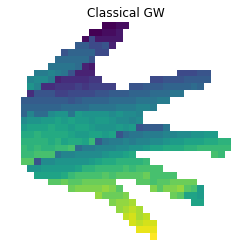

In [108]:
perm = plan_gw.argmax(axis=0)
# vertical gradient
binary = crop[::-1].astype(bool)
H, W = binary.shape
grad = np.linspace(0, 1, H)[:, None]
grad = np.repeat(grad, W, axis=1)

# convert gradient to colors
cmap = plt.cm.viridis
colors = cmap(grad)[..., :3][::-1]

# apply mask
colored = np.ones((H, W, 3))  # white background
transported_colors = colors.reshape(-1,3)[perm].reshape(colored.shape)
colored[binary] = transported_colors[binary]

plt.imshow(colored)
plt.axis("off")
plt.title('Classical GW')
plt.show()